In [2]:
import pandas as pd
import geopandas as gpd

ffw = gpd.read_parquet("../data/ffw_labeled_ws2024.parquet")

# Helene window: Sep 26-30 2024
helene = ffw[(ffw["ISSUED"] >= "2024-09-26") & (ffw["ISSUED"] <= "2024-09-30")].copy()

print(f"Total Helene warnings: {len(helene)}")
print(f"Verified: {helene['verified'].sum()} | Unverified: {(~helene['verified']).sum()}")
print()

# Show candidates — want a mix of verified/unverified, different WFOs
cols = ["WARNING_ID", "ISSUED", "EXPIRED", "WFO", "verified", 
        "n_lsr_inside", "AREA_KM2", "centroid_lon", "centroid_lat"]
print(helene[cols].sort_values("ISSUED").to_string())

Total Helene warnings: 192
Verified: 92 | Unverified: 100

      WARNING_ID                    ISSUED                   EXPIRED  WFO  verified  n_lsr_inside      AREA_KM2  centroid_lon  centroid_lat
3425        3425 2024-09-26 00:07:00+00:00 2024-09-26 05:00:00+00:00  GSP      True             4   1931.146277    -82.222350     35.581585
3586        3586 2024-09-26 00:10:00+00:00 2024-09-26 03:15:00+00:00  MRX      True             2   1909.662072    -81.944096     36.418057
3581        3581 2024-09-26 00:12:00+00:00 2024-09-26 04:15:00+00:00  TAE      True             5   5966.977644    -83.539842     31.528753
3608        3608 2024-09-26 00:15:00+00:00 2024-09-26 05:55:00+00:00  RNK      True             3   1382.802196    -81.237479     37.265839
3592        3592 2024-09-26 00:46:00+00:00 2024-09-26 05:45:00+00:00  GSP      True             1   1336.942074    -82.015411     36.026240
3546        3546 2024-09-26 00:47:00+00:00 2024-09-26 06:06:00+00:00  RNK      True             1   2

In [4]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from herbie import Herbie
import warnings
warnings.filterwarnings("ignore")

# ── The 3 case study warnings ──────────────────────────────────────────
ffw = gpd.read_parquet("../data/ffw_labeled_ws2024.parquet")

ids = [3393, 3330, 3632]
cases = ffw[ffw["WARNING_ID"].isin(ids)].copy()

labels = {
    3393: "Verified (19 LSRs) — TAE Panhandle FL",
    3330: "Unverified — RNK Virginia",
    3632: "Verified (7 LSRs) — MRX Appalachian Core"
}

for _, row in cases.iterrows():
    print(f"\nWARNING {row['WARNING_ID']}  |  {labels[row['WARNING_ID']]}")
    print(f"  Issued:   {row['ISSUED']}")
    print(f"  Expired:  {row['EXPIRED']}")
    print(f"  Centroid: ({row['centroid_lat']:.3f}°N, {row['centroid_lon']:.3f}°E)")
    print(f"  Area:     {row['AREA_KM2']:.0f} km²")
    print(f"  Verified: {row['verified']}  |  LSRs inside: {row['n_lsr_inside']}")


WARNING 3330  |  Unverified — RNK Virginia
  Issued:   2024-09-26 01:17:00+00:00
  Expired:  2024-09-26 06:02:00+00:00
  Centroid: (37.379°N, -78.802°E)
  Area:     790 km²
  Verified: False  |  LSRs inside: 0

WARNING 3393  |  Verified (19 LSRs) — TAE Panhandle FL
  Issued:   2024-09-26 21:17:00+00:00
  Expired:  2024-09-27 05:15:00+00:00
  Centroid: (30.434°N, -85.248°E)
  Area:     18232 km²
  Verified: True  |  LSRs inside: 19

WARNING 3632  |  Verified (7 LSRs) — MRX Appalachian Core
  Issued:   2024-09-27 13:14:00+00:00
  Expired:  2024-09-27 16:00:00+00:00
  Centroid: (36.168°N, -82.242°E)
  Area:     864 km²
  Verified: True  |  LSRs inside: 7


In [5]:
# Test with warning 3632 — small polygon, fast download
row = cases[cases["WARNING_ID"] == 3632].iloc[0]
issued = pd.Timestamp(row["ISSUED"]).tz_convert("UTC")

print(f"Fetching HRRR for: {issued}")
print(f"HRRR run: {issued.strftime('%Y-%m-%d %H:%M')} UTC")

H = Herbie(
    issued.strftime("%Y-%m-%d %H:%M"),
    model="hrrr",
    product="sfc",
    fxx=1,   # f01: 1-hour forecast valid at issuance time
)

print(f"\nHerbie object created successfully")
print(f"  Source: {H.grib}")

Fetching HRRR for: 2024-09-27 13:14:00+00:00
HRRR run: 2024-09-27 13:14 UTC
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2024-Sep-27 13:14 UTC F01 ┊ GRIB2 @ aws ┊ IDX @ local

Herbie object created successfully
  Source: https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrrr.20240927/conus/hrrr.t13z.wrfsfcf01.grib2


In [6]:
import xarray as xr

def get_hrrr_fields(issued_utc, fxx=1):
    """Download HRRR and extract PWAT, CAPE, REFC as xarray datasets."""
    H = Herbie(
        issued_utc.strftime("%Y-%m-%d %H:%M"),
        model="hrrr",
        product="sfc",
        fxx=fxx,
        verbose=False,
    )
    
    fields = {}
    
    # PWAT — precipitable water
    ds_pwat = H.xarray("PWAT:entire")
    fields["PWAT"] = ds_pwat["pwat"]
    
    # CAPE — surface-based
    ds_cape = H.xarray("CAPE:surface")
    fields["CAPE"] = ds_cape["cape"]
    
    # REFC — composite reflectivity
    ds_refc = H.xarray("REFC:entire")
    fields["REFC"] = ds_refc["refc"]
    
    return fields

# Extract for all 3 cases
print("Downloading HRRR fields for 3 Helene warnings...")
print("Each download is ~30-60 seconds\n")

hrrr_data = {}
for _, row in cases.iterrows():
    wid = row["WARNING_ID"]
    issued = pd.Timestamp(row["ISSUED"]).tz_convert("UTC")
    print(f"  Fetching WARNING {wid} — {issued.strftime('%Y-%m-%d %H:%M UTC')}...")
    hrrr_data[wid] = get_hrrr_fields(issued, fxx=1)
    print(f"    ✓ Done")

print("\nAll 3 downloaded. Fields available:", list(hrrr_data[3632].keys()))

Each download is ~30-60 seconds

  Fetching WARNING 3330 — 2024-09-26 01:17 UTC...
    ✓ Done
  Fetching WARNING 3393 — 2024-09-26 21:17 UTC...
    ✓ Done
  Fetching WARNING 3632 — 2024-09-27 13:14 UTC...
    ✓ Done

All 3 downloaded. Fields available: ['PWAT', 'CAPE', 'REFC']


In [12]:
lsr = pd.read_parquet("../data/lsr_clean_ws2024.parquet")

# Parse VALID column — format is 'YYYYMMDDHHMM'
lsr["valid_utc"] = pd.to_datetime(lsr["VALID"], format="%Y%m%d%H%M", utc=True)

helene_lsr = lsr[
    (lsr["valid_utc"] >= "2024-09-26") & 
    (lsr["valid_utc"] <= "2024-09-30")
].copy()

print(f"Helene LSRs: {len(helene_lsr)}")
print(helene_lsr[["valid_utc", "LON", "LAT", "WFO"]].head())

Helene LSRs: 297
                     valid_utc    LON    LAT  WFO
4418 2024-09-26 00:00:00+00:00 -81.25  37.26  RNK
4419 2024-09-26 00:00:00+00:00 -83.93  30.90  TAE
4420 2024-09-26 00:00:00+00:00 -83.89  30.90  TAE
4421 2024-09-26 00:11:00+00:00 -82.84  36.17  MRX
4422 2024-09-26 00:12:00+00:00 -83.47  35.86  MRX


In [14]:
# For each case warning, get LSRs that fall within its valid time window
def get_lsrs_for_warning(row, lsr_df):
    issued  = pd.Timestamp(row["ISSUED"]).tz_convert("UTC")
    expired = pd.Timestamp(row["EXPIRED"]).tz_convert("UTC")
    grace   = pd.Timedelta(minutes=60)
    mask = (lsr_df["valid_utc"] >= issued) & (lsr_df["valid_utc"] <= expired + grace)
    return lsr_df[mask].copy()

case_lsrs = {}
for _, row in cases.iterrows():
    wid = row["WARNING_ID"]
    matched = get_lsrs_for_warning(row, helene_lsr)
    case_lsrs[wid] = matched
    print(f"WARNING {wid}: {len(matched)} LSRs in time window")

WARNING 3330: 25 LSRs in time window
WARNING 3393: 58 LSRs in time window
WARNING 3632: 51 LSRs in time window


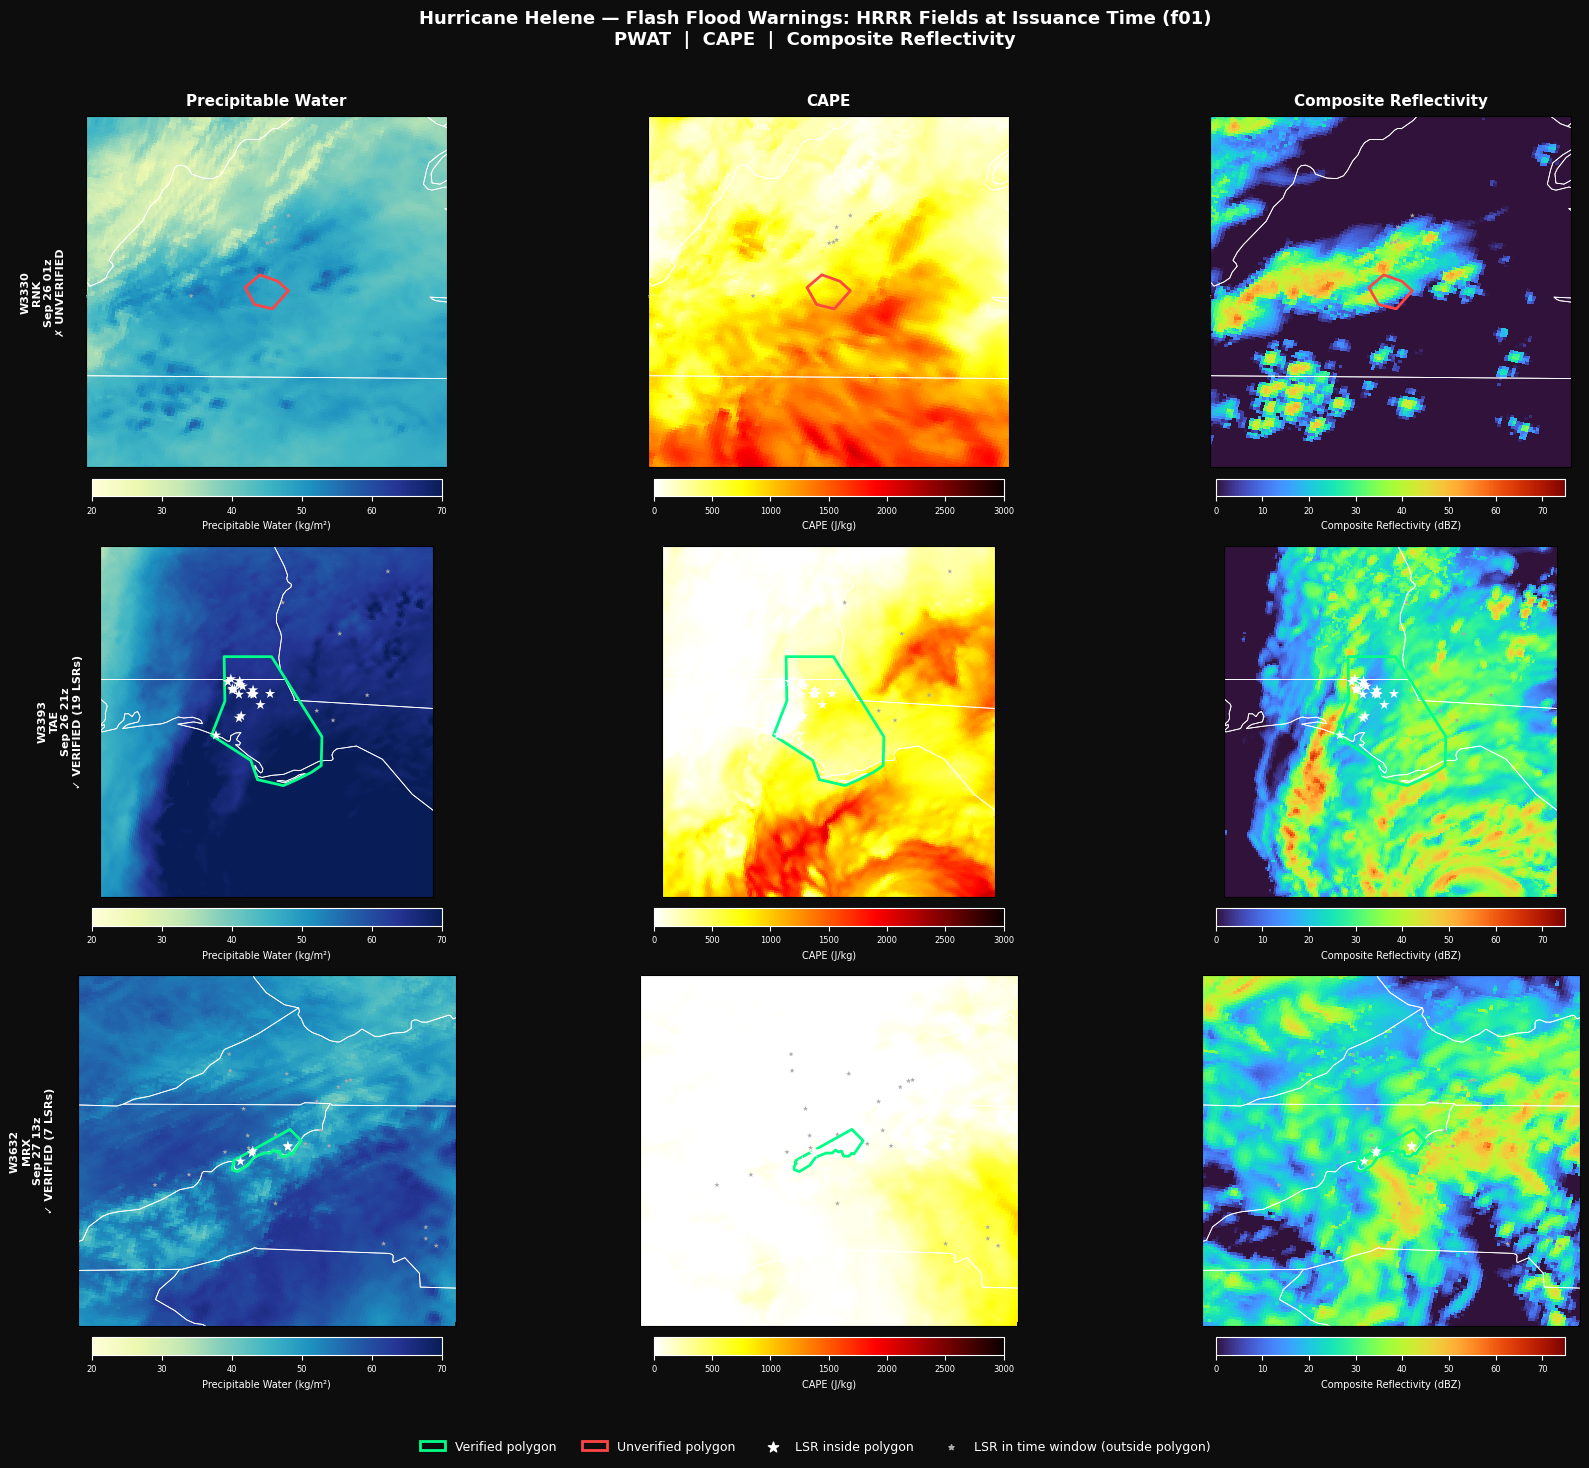

Saved → figures/helene_hrrr_3panel.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Point

PROJ = ccrs.PlateCarree()

var_cfg = {
    "PWAT": dict(cmap="YlGnBu", label="Precipitable Water (kg/m²)", vmin=20, vmax=70),
    "CAPE": dict(cmap="hot_r",  label="CAPE (J/kg)",                 vmin=0,  vmax=3000),
    "REFC": dict(cmap="turbo",  label="Composite Reflectivity (dBZ)", vmin=0,  vmax=75),
}

def pad_bounds(geom, deg=1.5):
    b = geom.bounds  # (minx, miny, maxx, maxy)
    return b[0]-deg, b[2]+deg, b[1]-deg, b[3]+deg

fig, axes = plt.subplots(
    3, 3,
    figsize=(18, 15),
    subplot_kw={"projection": PROJ},
)
fig.patch.set_facecolor("#0d0d0d")

warning_order = [3330, 3393, 3632]
var_order     = ["PWAT", "CAPE", "REFC"]

for row_i, wid in enumerate(warning_order):
    case_row = cases[cases["WARNING_ID"] == wid].iloc[0]
    polygon  = case_row["geometry"]
    lsrs_win = case_lsrs[wid]
    issued   = pd.Timestamp(case_row["ISSUED"]).tz_convert("UTC")
    verified = case_row["verified"]
    n_lsr    = case_row["n_lsr_inside"]

    x0, x1, y0, y1 = pad_bounds(polygon, deg=1.5)

    for col_i, var in enumerate(var_order):
        ax = axes[row_i, col_i]
        ax.set_facecolor("#0d0d0d")

        da    = hrrr_data[wid][var]
        cfg   = var_cfg[var]

        # ── FIX: convert 0-360 longitudes to -180/180 ──────────────
        lon2d = da.longitude.values.copy()
        lon2d[lon2d > 180] -= 360
        lat2d = da.latitude.values
        data  = da.values

        # Clip to plot extent
        mask = (
            (lon2d >= x0) & (lon2d <= x1) &
            (lat2d >= y0) & (lat2d <= y1)
        )

        if not mask.any():
            ax.set_title(f"{var} — no data in extent", color="white")
            continue

        # Get row/col indices bounding the mask
        rows = np.where(mask.any(axis=1))[0]
        cols = np.where(mask.any(axis=0))[0]
        r0, r1 = rows[0], rows[-1]+1
        c0, c1 = cols[0], cols[-1]+1

        im = ax.pcolormesh(
            lon2d[r0:r1, c0:c1],
            lat2d[r0:r1, c0:c1],
            data[r0:r1, c0:c1],
            cmap=cfg["cmap"],
            vmin=cfg["vmin"], vmax=cfg["vmax"],
            transform=PROJ, shading="auto", zorder=1,
        )

        ax.add_feature(cfeature.STATES.with_scale("50m"),
                       edgecolor="white", linewidth=0.6, zorder=2)
        ax.add_feature(cfeature.COASTLINE.with_scale("50m"),
                       edgecolor="white", linewidth=0.6, zorder=2)

        # Warning polygon
        color = "#00ff88" if verified else "#ff4444"
        ax.add_geometries(
            [polygon], crs=PROJ,
            facecolor="none", edgecolor=color,
            linewidth=2.0, zorder=3,
        )

        # LSR points
        for _, lsr_row in lsrs_win.iterrows():
            pt     = Point(lsr_row["LON"], lsr_row["LAT"])
            inside = pt.within(polygon)
            ax.scatter(
                lsr_row["LON"], lsr_row["LAT"],
                c="white" if inside else "#aaaaaa",
                s=60 if inside else 15,
                marker="*",
                transform=PROJ, zorder=5 if inside else 4,
                edgecolors="none",
            )

        ax.set_extent([x0, x1, y0, y1], crs=PROJ)

        cb = plt.colorbar(im, ax=ax, orientation="horizontal",
                          pad=0.03, fraction=0.046, shrink=0.85)
        cb.set_label(cfg["label"], color="white", fontsize=7)
        cb.ax.tick_params(colors="white", labelsize=6)
        cb.outline.set_edgecolor("white")

        if row_i == 0:
            ax.set_title(cfg["label"].split(" (")[0],
                         color="white", fontsize=11, fontweight="bold", pad=8)

    status = f"✓ VERIFIED ({n_lsr} LSRs)" if verified else "✗ UNVERIFIED"
    axes[row_i, 0].text(
        -0.12, 0.5,
        f"W{wid}\n{case_row['WFO']}\n{issued.strftime('%b %d %Hz')}\n{status}",
        transform=axes[row_i, 0].transAxes,
        va="center", ha="center", color="white",
        fontsize=8, fontweight="bold", rotation=90,
    )

legend_elements = [
    mpatches.Patch(facecolor="none", edgecolor="#00ff88", linewidth=2, label="Verified polygon"),
    mpatches.Patch(facecolor="none", edgecolor="#ff4444", linewidth=2, label="Unverified polygon"),
    plt.scatter([], [], c="white",    s=60, marker="*", label="LSR inside polygon"),
    plt.scatter([], [], c="#aaaaaa",  s=15, marker="*", label="LSR in time window (outside polygon)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4,
           frameon=False, fontsize=9,
           labelcolor="white", bbox_to_anchor=(0.5, 0.01))

fig.suptitle(
    "Hurricane Helene — Flash Flood Warnings: HRRR Fields at Issuance Time (f01)\n"
    "PWAT  |  CAPE  |  Composite Reflectivity",
    color="white", fontsize=13, fontweight="bold", y=0.98,
)

plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.savefig("../figures/helene_hrrr_3panel.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("Saved → figures/helene_hrrr_3panel.png")